# Вычислительный практикум

## Практическое занятие \#2.2. Приближение функций. $B$-сплайны

### Основные сведения

#### Постановка задачи приближения функций

Пусть $a<b$, а $f:[a,b]\to\mathbb{R}$ — функция, значения которой известны в $M+1$ попарно различных точках

$$
a\leqslant x_0<x_1<\ldots<x_M\leqslant b,\quad y_j=f(x_j),\quad j=0,\dots,M.
$$

Для постановки задачи по табличным данным достаточно, чтобы числа $y_j$ были заданы. При сравнении приближения с исходной функцией будем считать, что $f\in C([a,b])$. Если исследуются производные или теоретические оценки погрешности сплайна степени $p$, дополнительно предполагают требуемую гладкость функции, так далее при необходимости будем считать, что $f\in C^{p+1}([a,b])$.

Требуется построить сплайн $S$ степени $p$, который приближает $f$ на $[a,b]$. Коэффициенты сплайна можно выбрать из условий интерполяции

$$
S(x_j)=y_j,\quad j=0,\dots,M,
$$

либо из условия наилучшего приближения, например методом наименьших квадратов. В отличие от одного глобального полинома высокой степени, сплайн состоит из полиномиальных фрагментов, согласованных в узлах с заданной гладкостью.

#### Узловой вектор и пространство сплайнов

Зафиксируем степень $p\geqslant 0$ и неубывающий узловой вектор

$$
\boldsymbol{t}=(t_0,t_1,\dots,t_m),\qquad t_0\leqslant t_1\leqslant\dots\leqslant t_m.
$$

Если используется $n+1$ базисных функций, то индексы связаны равенством

$$
m=n+p+1,
$$

то есть длина узлового вектора равна $m+1=n+p+2$. Рабочая область базиса имеет вид $[t_p,t_{n+1}]$. Для приближения на $[a,b]$ выбирают $t_p=a$ и $t_{n+1}=b$.

Узловой вектор называют равномерным, если соседние различные узлы расположены с постоянным шагом, и неравномерным — в противном случае. В открытом закрепленном (clamped) векторе граничные узлы повторяются $p+1$ раз:

$$
t_0=\dots=t_p=a,\qquad t_{n+1}=\dots=t_m=b.
$$

Например, для $p=3$ и $n+1=6$ можно взять

$$
\boldsymbol{t}=(0,0,0,0,1,2,3,3,3,3).
$$

Скалярный $B$-сплайн записывается как

$$
S(x)=\sum_{i=0}^{n}c_iN_{i,p}(x),\qquad x\in[t_p,t_{n+1}],
$$

где $N_{i,p}$ — базисные $B$-сплайны, а $c_i$ — коэффициенты. В общем случае $c_i$ не являются значениями $f$ в узлах $t_i$.

#### Построение базисных функций. Рекурсивный алгоритм Кокса — де Бура

Базисные функции нулевой степени определяются равенством

$$
N_{i,0}(x)=
\begin{cases}
1,&t_i\leqslant x<t_{i+1},\\
0,&\text{иначе}.
\end{cases}
$$

При $p\geqslant 1$ используется рекуррентная формула

$$
N_{i,p}(x)=
\frac{x-t_i}{t_{i+p}-t_i}N_{i,p-1}(x)
+\frac{t_{i+p+1}-x}{t_{i+p+1}-t_{i+1}}N_{i+1,p-1}(x).
$$

Если знаменатель одной из дробей равен нулю, соответствующее слагаемое полагают равным нулю. Значение на правом конце $x=t_{n+1}$ задают по непрерывному продолжению слева. Для закрепленного узлового вектора это обеспечивает $N_{n,p}(t_{n+1})=1$.

Рекурсия начинается с кусочно-постоянных функций $N_{i,0}$, затем строит линейные функции $N_{i,1}$, квадратичные $N_{i,2}$ и далее функции требуемой степени. Поэтому для вычисления одного $N_{i,p}$ используются только базисные функции меньшей степени с соседними индексами.

#### Выбор коэффициентов сплайна

Для заданных точек $x_j$ составим матрицу значений базисных функций

$$
A_{ji}=N_{i,p}(x_j),\qquad j=0,\dots,M,\quad i=0,\dots,n.
$$

В задаче интерполяции коэффициенты $\boldsymbol{c}=(c_0,\dots,c_n)^{\text{T}}$ находят из системы

$$
A\boldsymbol{c}=\boldsymbol{y}.
$$

Если число условий совпадает с числом коэффициентов и матрица $A$ невырождена, решение единственно. Расположение узлов сплайна и точек интерполяции должно обеспечивать разрешимость системы.

Если данных больше, чем коэффициентов, можно использовать метод наименьших квадратов:

$$
\min_{\boldsymbol{c}}\|A\boldsymbol{c}-\boldsymbol{y}\|_2^2.
$$

В этом случае сплайн обычно не проходит через все исходные точки, а приближает данные по выбранному критерию. Для вычислений на Python можно использовать функции модуля `scipy.interpolate`, однако способ формирования узлового вектора, степень сплайна и смысл найденных коэффициентов должны быть указаны явно.

#### Алгоритм де Бура

После нахождения коэффициентов значение $S(x)$ можно вычислять по сумме базисных функций. Более эффективный способ — алгоритм де Бура, являющийся сплайновым аналогом алгоритма де Кастельжо.

Пусть $t_k\leqslant x<t_{k+1}$. Для правого конца области полагают $k=n$. Введем начальные значения

$$
d_j^{(0)}=c_{k-p+j},\quad j=0,\dots,p.
$$

Далее для $r=1,\dots,p$ и $j=p,p-1,\dots,r$ вычисляют

$$
\alpha_{j,r}=\frac{x-t_{k-p+j}}{t_{k+1+j-r}-t_{k-p+j}},
$$

$$
d_j^{(r)}=(1-\alpha_{j,r})d_{j-1}^{(r-1)}+\alpha_{j,r}d_j^{(r-1)}.
$$

Результатом является $S(x)=d_p^{(p)}$. При программной реализации промежуточные значения можно хранить в одном массиве и обновлять в обратном порядке по $j$.

#### $B$-сплайновые кривые и NURBS

Тот же базис используется для задания параметрической кривой. Если $P_i\in\mathbb{R}^d$ — контрольные точки, то

$$
C(u)=\sum_{i=0}^{n}N_{i,p}(u)P_i,\qquad u\in[t_p,t_{n+1}].
$$

Для открытого закрепленного узлового вектора кривая проходит через крайние контрольные точки: $C(t_p)=P_0$ и $C(t_{n+1})=P_n$. Остальные контрольные точки в общем случае не лежат на кривой.

При положительных весах $w_i$ получают неравномерный рациональный $B$-сплайн (NURBS):

$$
C(u)=\frac{\sum_{i=0}^{n}N_{i,p}(u)w_iP_i}{\sum_{i=0}^{n}N_{i,p}(u)w_i}.
$$

#### Основные свойства $B$-сплайнов

1. **Локальный носитель.**

    Функция $N_{i,p}$ может быть ненулевой только на $[t_i,t_{i+p+1})$. Поэтому изменение одного коэффициента $c_i$ влияет лишь на часть сплайна.
   
4. **Неотрицательность.**

    На рабочей области $N_{i,p}(x)\geqslant 0$.

7. **Разбиение единицы.**

    На $[t_p,t_{n+1}]$ выполняется $\sum_{i=0}^{n}N_{i,p}(x)=1$.

9. **Кусочно-полиномиальная структура.**

    На каждом промежутке между соседними различными узлами сплайн является полиномом степени не выше $p$.

11. **Гладкость.**

    Во внутреннем узле кратности $\mu$ сплайн имеет непрерывность $C^{p-\mu}$. В частности, в простом узле — $C^{p-1}$. Увеличение кратности узла уменьшает гладкость.

13. **Выпуклая оболочка.**

    Участок $B$-сплайновой кривой находится в выпуклой оболочке влияющих на него контрольных точек.

## Задания

1. Реализовать на Python вычисление базисных функций $N_{i,p}(x)$ по алгоритму Кокса — де Бура. Учесть нулевые знаменатели, повторяющиеся узлы и правый конец рабочей области. На основе этой функции реализовать вычисление $S(x)=\sum_{i=0}^{n}c_iN_{i,p}(x)$.
2. Для степеней $p=1,2,3$ построить открытые закрепленные равномерные узловые векторы на выбранном отрезке и изобразить все базисные функции. На плотной сетке численно проверить неотрицательность базиса и равенство $\sum_iN_{i,p}(x)=1$. Вывести результаты на печать. Для построение этих сплайнов удобно воспользоваться библиотекой `SymPy`.
3. Для функции $f(x)=\sin (x)$ на отрезке $[-\pi,\pi]$ сформировать таблицу значений в равноотстоящих точках. Построить интерполирующий кубический $B$-сплайн. Указать степень, узловой вектор, число коэффициентов и способ их определения. Сравнить значения приближений с $f$ на исходных узлах и на сгущенной контрольной сетке.
4. Реализовать алгоритм де Бура для вычисления построенного сплайна. Сравнить его результаты со значениями, полученными через явную сумму базисных функций и с помощью `scipy.interpolate.BSpline`. Оценить максимальное расхождение.
5. Исследовать влияние степени сплайна, числа и расположения внутренних узлов на результат приближения. Для каждого варианта вычислить на общей контрольной сетке максимальную абсолютную погрешность

   $$
       E_{\infty}=\max_k|f(x_k^{*})-S(x_k^{*})|
   $$

   и среднеквадратическую погрешность. Представить результаты на графиках и в таблице.
6. Рассмотреть функцию Рунге

   $$
       f(x)=\frac{1}{1+25x^2},\qquad x\in[-1,1].
   $$

   Для нескольких наборов равноотстоящих узлов построить интерполирующие кубические $B$-сплайны. Сравнить их с исходной функцией по графикам, таблицам значений и величинам погрешности на плотной контрольной сетке. Интерпретировать влияние числа узлов на полученные результаты. Сравнить с результатами, которые были получены с применением интерполяционных полиномов.
7. Подготовить отчет о выполнении работы. Отчет должен содержать:
   - постановку задачи с указанием функции $f$, отрезка, исходных узлов, степени сплайна и узлового вектора;
   - краткое описание используемых методов и последовательности решения;
   - описание входных данных и ожидаемых результатов: коэффициентов сплайна, таблиц значений, графиков и оценок погрешности;
   - программную реализацию и результаты вычислений;
   - интерпретацию результатов, сравнение рассмотренных вариантов и выводы.

Для вычислительных экспериментов рекомендуется привести таблицу **«Сравнение значений исходной функции и $B$-сплайновых приближений»** со столбцами $x_k^{*}$, $f(x_k^{*})$, $S_{\mathrm{int}}(x_k^{*})$, $|f(x_k^{*})-S_{\mathrm{int}}(x_k^{*})|$, $S_{\mathrm{LS}}(x_k^{*})$ и $|f(x_k^{*})-S_{\mathrm{LS}}(x_k^{*})|$.

**НОМЕР ОДИН**

In [1]:
import sympy as sp

def N(i, p, x, t):
    n = len(t) - p - 2
    right_end = t[n + 1]
    if x == right_end:
        return 1.0 if i == n else 0.0
    if p == 0:
        return 1.0 if t[i] <= x < t[i + 1] else 0.0

    left = 0.0
    right = 0.0

    den_left = t[i + p] - t[i]
    den_right = t[i + p + 1] - t[i + 1]

    if den_left != 0:
        left = ((x - t[i]) / den_left * N(i, p - 1, x, t))

    if den_right != 0:
        right = ((t[i + p + 1] - x) / den_right * N(i + 1, p - 1, x, t))

    return left + right

In [2]:
def S(x, t, p, c):
    return sum(c[i] * N(i, p, x, t) for i in range(len(c)))

**НОМЕР ДВА**

In [ ]:
def open_uniform_knots(a, b, h, p):
    inner = list(range(a + h, b, h))
    knots = ([a] * (p + 1) + inner + [b] * (p + 1))

    return knots

p = 1
knots = [-5, -5, -3, -1, 1, 3, 5, 5]
Все базисные функции >= 0: True
Максимальная ошибка суммы: 0

p = 2
knots = [-5, -5, -5, -3, -1, 1, 3, 5, 5, 5]
Все базисные функции >= 0: True
Максимальная ошибка суммы: 1.1102230246251565e-16

p = 3
knots = [-5, -5, -5, -5, -3, -1, 1, 3, 5, 5, 5, 5]
Все базисные функции >= 0: True
Максимальная ошибка суммы: 2.220446049250313e-16



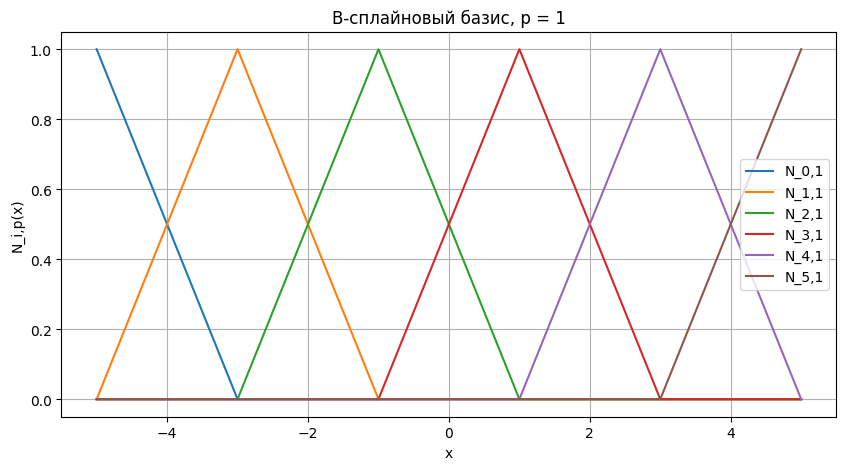

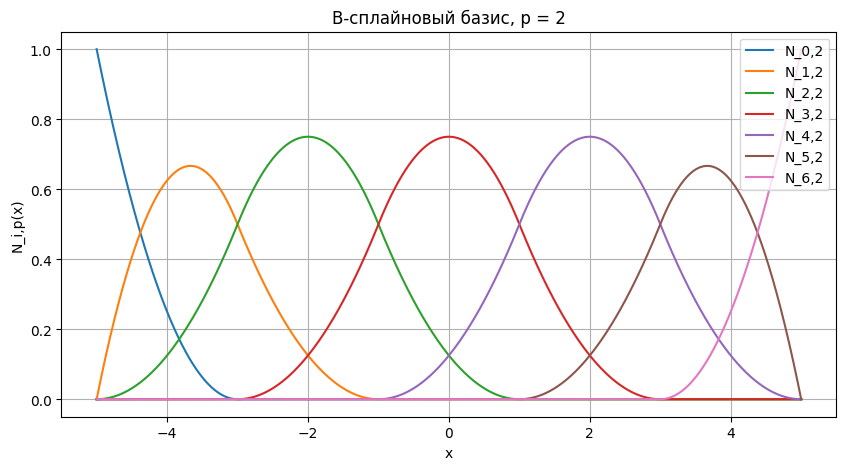

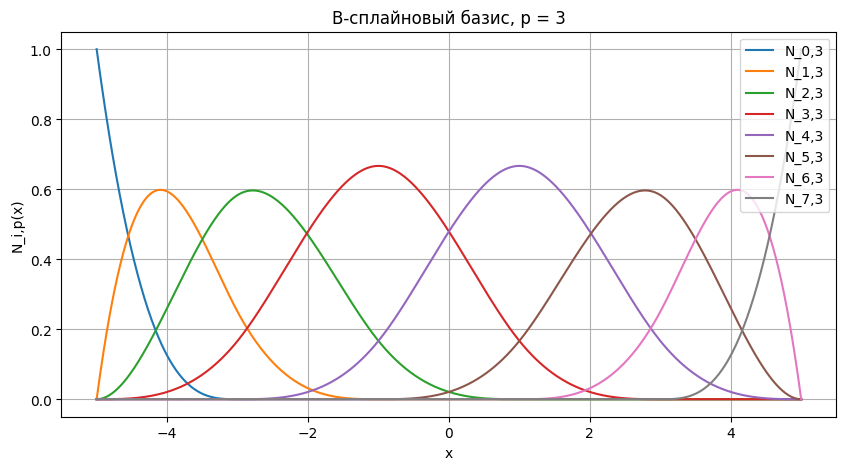

In [8]:
import matplotlib.pyplot as plt

a = -5
b = 5
h = 2

x_grid = [a + (b - a) * i / 1000 for i in range(1001)]

for p in [1, 2, 3]:
    knots = open_uniform_knots(a, b, h, p)
    num_basis = len(knots) - p - 1

    print("p =", p)
    print("knots =", knots)

    all_nonnegative = True
    max_sum_error = 0

    for x in x_grid:
        values = [N(i, p, x, knots) for i in range(num_basis)]

        if any(v < -1e-12 for v in values):  # вот эта штука -1e-12 для обработки флоат нулей
            all_nonnegative = False

        s = sum(values)
        error = abs(s - 1)

        if error > max_sum_error:
            max_sum_error = error

    print("Все базисные функции >= 0:", all_nonnegative)
    print("Максимальная ошибка суммы:", max_sum_error)
    print()

for p in [1, 2, 3]:
  knots = open_uniform_knots(a, b, h, p)
  num_basis = len(knots) - p - 1
  plt.figure(figsize=(10, 5))

  for i in range(num_basis):
      y = [N(i, p, x, knots) for x in x_grid]

      plt.plot(
          x_grid,
          y,
          label=f"N_{i},{p}"
          )

  plt.title(f"B-сплайновый базис, p = {p}")
  plt.xlabel("x")
  plt.ylabel("N_i,p(x)")
  plt.grid()
  plt.legend()
  plt.show()

**НОМЕР ТРИ**

-pi 0
-3*pi/4 -sqrt(2)/2
-pi/2 -1
-pi/4 -sqrt(2)/2
0 0
pi/4 sqrt(2)/2
pi/2 1
3*pi/4 sqrt(2)/2
pi 0
[-pi, -pi, -pi, -pi, -2*pi/3, -pi/3, 0, pi/3, 2*pi/3, pi, pi, pi, pi]
Длина = 13
A =
⎡  1.0         0           0                0                   0              ↪
⎢                                                                              ↪
⎢0.015625  0.45703125  0.45703125       0.0703125               0              ↪
⎢                                                                              ↪
⎢   0       0.03125     0.46875     0.479166666666667   0.0208333333333333     ↪
⎢                                                                              ↪
⎢   0          0       0.0703125    0.611979166666667   0.315104166666667   0. ↪
⎢                                                                              ↪
⎢   0          0           0        0.166666666666667   0.666666666666667    0 ↪
⎢                                                                              ↪
⎢   0 

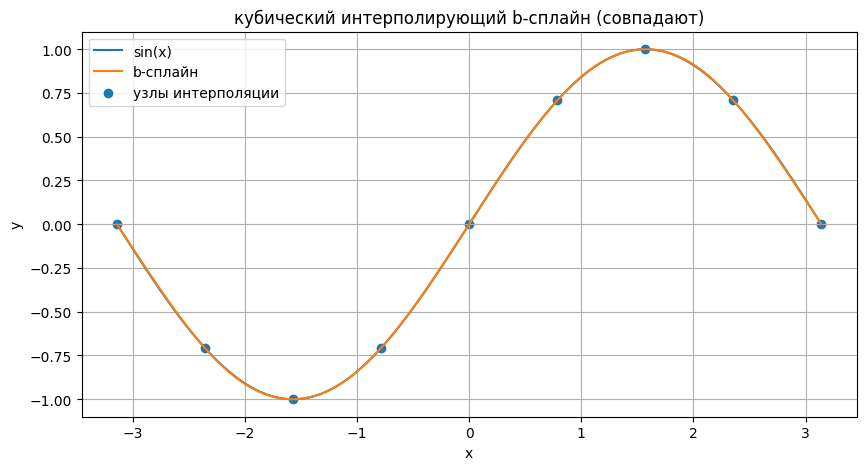

Максимальная ошибка: 0.004980101018689398


In [10]:
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols("x")
f = sp.sin(x) # функция
p = 3 # степень сплайна
M = 8 # число точек интерполяции

nodes = [-sp.pi + 2 * sp.pi * j / M for j in range(M + 1)]
values = [sp.sin(xj) for xj in nodes]
for xj, yj in zip(nodes, values):
    print(xj, yj)

n = 8
num_inner = n - p
inner = [-sp.pi + 2 * sp.pi * k / (num_inner + 1) for k in range(1, num_inner + 1)]
knots = ([-sp.pi] * (p + 1) + inner + [sp.pi] * (p + 1))

print(knots)
print("Длина =", len(knots))

A = sp.Matrix([[N(i, p, nodes[j], knots) for i in range(n + 1)] for j in range(M + 1)])
Y = sp.Matrix(values)
print("A =")
sp.pprint(A)

C = A.LUsolve(Y)
print("Коэффициенты:")
sp.pprint(C)

print("Проверка в исходных узлах:")
for j in range(len(nodes)):
    sj = S(nodes[j], knots, p, C)
    print(
        "x =", nodes[j],
        "f(x) =", sp.N(values[j], 8),
        "S(x) =", sp.N(sj, 8),
        "error =", sp.N(abs(values[j] - sj), 8)
    )

x_test = [-sp.pi + 2 * sp.pi * k / 200 for k in range(201)]
f_test = [float(sp.sin(xi)) for xi in x_test]
s_test = [float(S(xi, knots, p, C)) for xi in x_test]

plt.figure(figsize=(10, 5))

plt.plot(
    [float(xi) for xi in x_test],
    f_test,
    label="sin(x)"
)

plt.plot(
    [float(xi) for xi in x_test],
    s_test,
    label="b-сплайн"
)

plt.scatter(
    [float(xi) for xi in nodes],
    [float(yi) for yi in values],
    label="узлы интерполяции"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("кубический интерполирующий b-сплайн (совпадают)")
plt.grid()
plt.legend()
plt.show()

errors = [abs(f_test[k] - s_test[k]) for k in range(len(x_test))]

print("Максимальная ошибка:", max(errors))

**НОМЕР ЧЕТЫРЕ**

In [11]:
def de_boor(x, knots, coeffs, p):
    n = len(coeffs) - 1
    if x == knots[n + 1]: k = n
    else:
      k = None
      for i in range(p, n + 1):
          if knots[i] <= x < knots[i + 1]:
              k = i
              break
    if k is None:
        raise ValueError("x находится вне отрезка")

    d = [coeffs[k - p + j] for j in range(p + 1)]

    for r in range(1, p + 1):
        for j in range(p, r - 1, -1):
            left_index = k - p + j
            right_index = k + 1 + j - r
            denominator = (knots[right_index] - knots[left_index])

            if denominator == 0:
                alpha = 0
            else:
                alpha = (x - knots[left_index]) / denominator

            d[j] = ((1 - alpha) * d[j - 1] + alpha * d[j])
    return d[p]

In [12]:
x_test = [-sp.pi + 2 * sp.pi * k / 500 for k in range(501)]
sum_values = [float(S(xi, knots, p, C)) for xi in x_test]
deboor_values = [float(de_boor(xi, knots, C, p)) for xi in x_test]
diff_sum_deboor = [abs(sum_values[i] - deboor_values[i]) for i in range(len(x_test))]

print("Максимальное расхождение сумма / де Бур:", max(diff_sum_deboor))

Максимальное расхождение сумма / де Бур: 5.551115123125783e-16


In [13]:
from scipy.interpolate import BSpline

knots_float = [float(t) for t in knots]
coeffs_float = [float(c) for c in C]

scipy_spline = BSpline(knots_float, coeffs_float, p)
scipy_values = [float(scipy_spline(float(xi))) for xi in x_test]

diff_sum_scipy = [abs(sum_values[i] - scipy_values[i])for i in range(len(x_test))]
diff_deboor_scipy = [abs(deboor_values[i] - scipy_values[i]) for i in range(len(x_test))]

print("Максимальное расхождение сумма / SciPy:", max(diff_sum_scipy))
print("Максимальное расхождение де Бур / SciPy:", max(diff_deboor_scipy))

Максимальное расхождение сумма / SciPy: 5.551115123125783e-16
Максимальное расхождение де Бур / SciPy: 5.551115123125783e-16


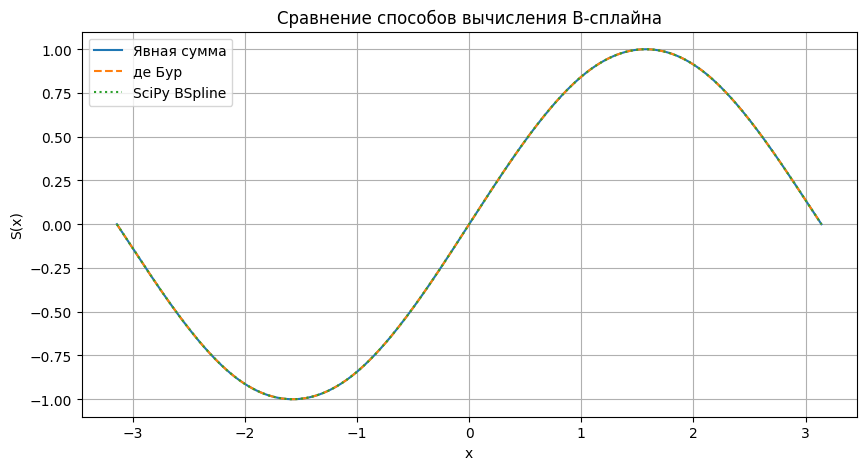

In [14]:
plt.figure(figsize=(10, 5))

x_float = [float(xi) for xi in x_test]

plt.plot(
    x_float,
    sum_values,
    label="Явная сумма"
)

plt.plot(
    x_float,
    deboor_values,
    "--",
    label="де Бур"
)

plt.plot(
    x_float,
    scipy_values,
    ":",
    label="SciPy BSpline"
)

plt.xlabel("x")
plt.ylabel("S(x)")
plt.title("Сравнение способов вычисления B-сплайна")
plt.grid()
plt.legend()
plt.show()

**НОМЕР ПЯТЬ**

In [15]:
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
from math import sqrt

x = sp.symbols("x")
f = sp.sin(x)

a = -sp.pi
b = sp.pi
x_test = [a + (b - a) * k / 500 for k in range(501)]
f_test = [float(f.subs(x, xi)) for xi in x_test]

results = []

for p in [1, 2, 3]:
    for num_inner in [3, 5, 7]:
        n = num_inner + p
        num_basis = n + 1
        nodes = [a + (b - a) * j / n for j in range(n + 1)]
        values = [f.subs(x, xi) for xi in nodes]
        inner = [a + (b - a) * k / (num_inner + 1) for k in range(1, num_inner + 1)]
        knots = [a] * (p + 1) + inner + [b] * (p + 1)
        A = sp.Matrix([[N(i, p, nodes[j], knots) for i in range(num_basis)] for j in range(num_basis)])
        Y = sp.Matrix(values)
        C = A.LUsolve(Y)
        s_test = [float(S(xi, knots, p, C)) for xi in x_test]
        errors = [abs(f_test[k] - s_test[k]) for k in range(len(x_test))]
        max_error = max(errors)
        rms_error = sqrt(sum(e ** 2 for e in errors) / len(errors))
        results.append([p, num_inner, num_basis, max_error, rms_error])

table = pd.DataFrame(results, columns=["p", "Внутренних узлов", "Базисных функций", "E_inf", "E_RMS"])
table

,p,Внутренних узлов,Базисных функций,E_inf,E_RMS
0,1,3,5,0.210513,0.150726
1,1,5,7,0.133975,0.069040
2,1,7,9,0.070365,0.039245
3,2,3,6,0.067974,0.036245
4,2,5,8,0.016698,0.008377
5,2,7,10,0.006052,0.003121
6,3,3,7,0.016639,0.008922
7,3,5,9,0.004984,0.002278
8,3,7,11,0.001225,0.000439


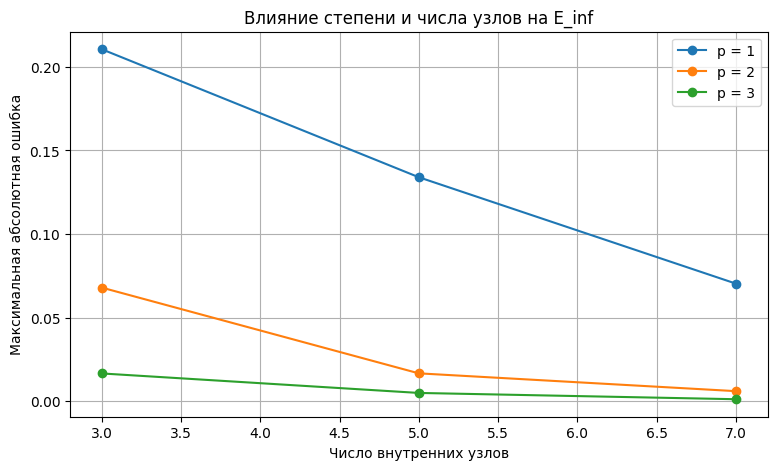

In [16]:
plt.figure(figsize=(9, 5))

for p in [1, 2, 3]:
    part = table[table["p"] == p]
    plt.plot(part["Внутренних узлов"], part["E_inf"], marker="o", label=f"p = {p}")

plt.xlabel("Число внутренних узлов")
plt.ylabel("Максимальная абсолютная ошибка")
plt.title("Влияние степени и числа узлов на E_inf")
plt.grid()
plt.legend()
plt.show()

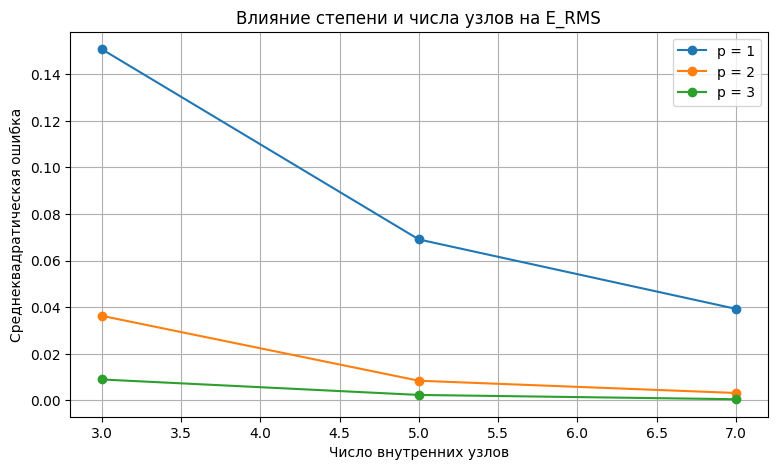

In [17]:
plt.figure(figsize=(9, 5))

for p in [1, 2, 3]:
    part = table[table["p"] == p]
    plt.plot(part["Внутренних узлов"], part["E_RMS"], marker="o", label=f"p = {p}")

plt.xlabel("Число внутренних узлов")
plt.ylabel("Среднеквадратическая ошибка")
plt.title("Влияние степени и числа узлов на E_RMS")
plt.grid()
plt.legend()
plt.show()

In [18]:
p = 3
num_inner = 5
n = num_inner + p
num_basis = n + 1
nodes = [a + (b - a) * j / n for j in range(n + 1)]
values = [f.subs(x, xi) for xi in nodes]

inner_uniform = [a + (b - a) * k / (num_inner + 1) for k in range(1, num_inner + 1)]
inner_center = [-sp.pi / 2, -sp.pi / 4, 0, sp.pi / 4, sp.pi / 2]

placement_results = []

for name, inner in [("Равномерные", inner_uniform), ("Сгущенные к центру", inner_center)]:
    knots = [a] * (p + 1) + inner + [b] * (p + 1)
    A = sp.Matrix([[N(i, p, nodes[j], knots) for i in range(num_basis)] for j in range(num_basis)])
    Y = sp.Matrix(values)
    C = A.LUsolve(Y)
    s_test = [float(S(xi, knots, p, C)) for xi in x_test]
    errors = [abs(f_test[k] - s_test[k]) for k in range(len(x_test))]
    max_error = max(errors)
    rms_error = sqrt(sum(e ** 2 for e in errors) / len(errors))
    placement_results.append([name, max_error, rms_error])

placement_table = pd.DataFrame(placement_results, columns=["Расположение узлов", "E_inf", "E_RMS"])
placement_table

,Расположение узлов,E_inf,E_RMS
0,Равномерные,0.004984,0.002278
1,Сгущенные к центру,0.007747,0.002940


1. увеличение числа внутренних узлов приводит к уменьшению максимальной и среднеквадратической ошибок аппроксимации
2. повышение степени b-сплайна также улучшает точность: среди рассмотренных вариантов наименьшие ошибки получены для кубического сплайна
3. для функции синуса на выбранном интервале равномерное расположение внутренних узлов показало меньшую погрешность, чем использованное сгущение узлов к центру

**НОМЕР ШЕСТЬ**

In [19]:
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
from math import sqrt

x = sp.symbols("x")
f_runge = 1 / (1 + 25 * x**2)

a = -1
b = 1
p = 3

x_test = [a + (b - a) * k / 1000 for k in range(1001)]
f_test = [float(f_runge.subs(x, xi)) for xi in x_test]

results = []
splines = {}

for num_nodes in [9, 21]:
    n = num_nodes - 1
    num_basis = num_nodes
    nodes = [a + (b - a) * j / n for j in range(num_nodes)]
    values = [f_runge.subs(x, xi) for xi in nodes]
    num_inner = n - p
    inner = [a + (b - a) * k / (num_inner + 1) for k in range(1, num_inner + 1)]
    knots = [a] * (p + 1) + inner + [b] * (p + 1)
    A = sp.Matrix([[N(i, p, nodes[j], knots) for i in range(num_basis)] for j in range(num_nodes)])
    Y = sp.Matrix(values)
    C = A.LUsolve(Y)
    s_test = [float(S(xi, knots, p, C)) for xi in x_test]
    errors = [abs(f_test[k] - s_test[k]) for k in range(len(x_test))]
    max_error = max(errors)
    rms_error = sqrt(sum(e**2 for e in errors) / len(errors))
    results.append([num_nodes, num_inner, max_error, rms_error])
    splines[num_nodes] = [nodes, values, knots, C, s_test]

table = pd.DataFrame(results, columns=["Число узлов", "Внутренних knots", "E_inf", "E_RMS"])
table

,Число узлов,Внутренних knots,E_inf,E_RMS
0,9,5,0.154770,0.076004
1,21,17,0.012198,0.003170


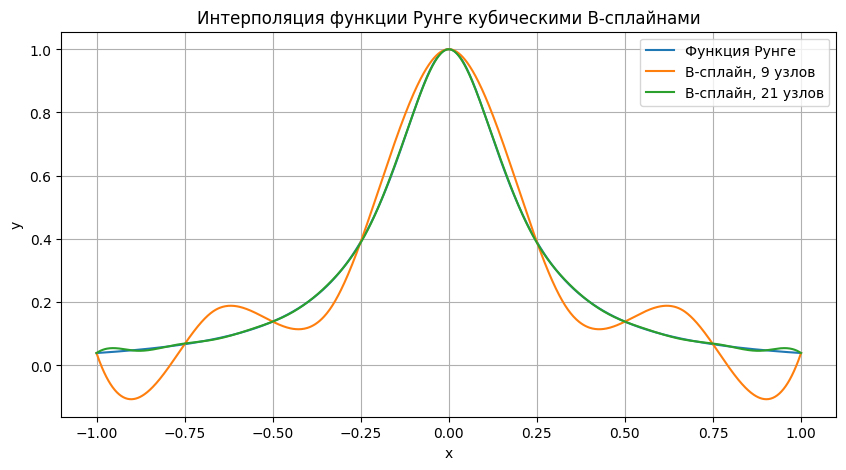

In [20]:
plt.figure(figsize=(10, 5))

plt.plot([float(xi) for xi in x_test], f_test, label="Функция Рунге")

for num_nodes in [9, 21]:
    plt.plot([float(xi) for xi in x_test], splines[num_nodes][4], label=f"B-сплайн, {num_nodes} узлов")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Интерполяция функции Рунге кубическими B-сплайнами")
plt.grid()
plt.legend()
plt.show()

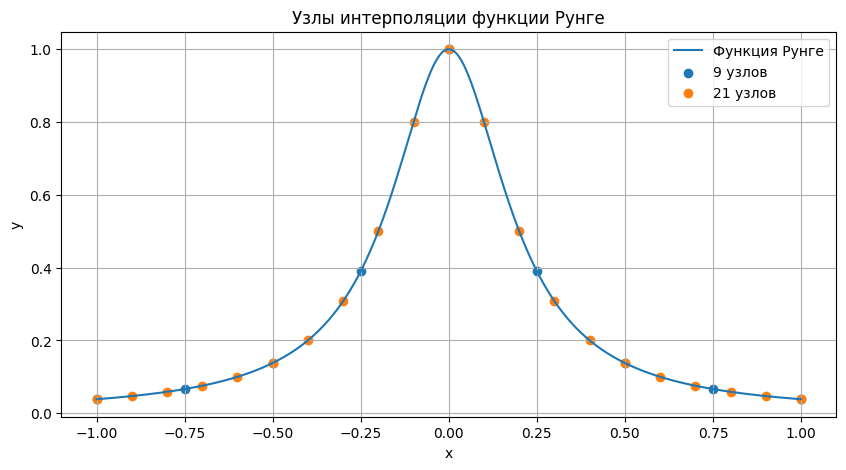

In [21]:
plt.figure(figsize=(10, 5))

plt.plot([float(xi) for xi in x_test], f_test, label="Функция Рунге")

for num_nodes in [9, 21]:
    nodes = splines[num_nodes][0]
    values = splines[num_nodes][1]
    plt.scatter([float(xi) for xi in nodes], [float(yi) for yi in values], label=f"{num_nodes} узлов")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Узлы интерполяции функции Рунге")
plt.grid()
plt.legend()
plt.show()

In [22]:
control_points = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]

rows = []

for xi in control_points:
    fx = float(f_runge.subs(x, xi))
    s9 = float(S(xi, splines[9][2], p, splines[9][3]))
    s21 = float(S(xi, splines[21][2], p, splines[21][3]))
    rows.append([xi, fx, s9, abs(fx - s9), s21, abs(fx - s21)])

comparison = pd.DataFrame(rows, columns=["x", "f(x)", "S_9(x)", "|f-S_9|", "S_21(x)", "|f-S_21|"])
comparison

,x,f(x),S_9(x),|f-S_9|,S_21(x),|f-S_21|
0,-1.00,0.038462,0.038462,0.000000e+00,0.038462,0.000000e+00
1,-0.75,0.066390,0.066390,1.387779e-17,0.068657,2.267280e-03
2,-0.50,0.137931,0.137931,2.775558e-17,0.137931,0.000000e+00
3,-0.25,0.390244,0.390244,5.551115e-17,0.387783,2.460467e-03
4,0.00,1.000000,1.000000,2.220446e-16,1.000000,1.110223e-16
5,0.25,0.390244,0.390244,1.665335e-16,0.387783,2.460467e-03
6,0.50,0.137931,0.137931,0.000000e+00,0.137931,2.775558e-17
7,0.75,0.066390,0.066390,1.387779e-17,0.068657,2.267280e-03
8,1.00,0.038462,0.038462,0.000000e+00,0.038462,0.000000e+00


1. При увеличении числа узлов кубический b-сплайн лучше приближает функцию Рунге, а максимальная и среднеквадратическая ошибки уменьшаются
2. В отличие от интерполяционного полинома, выбросов на концах интервала не наблюдается

**НОМЕР СЕМЬ. ИТОГИ**

1. реализовал базисные функции b-сплайнов и построил интерполирующие сплайны различных степеней
2. проверил основные свойства b-сплайнового базиса т.к. неотрицательность базисных функций и равенство их суммы единице
3. значения сплайна, вычисленные через явную сумму, алгоритм де Бура и scipy, практически совпали; расхождения сравнимы с погрешностью
4. эксперименты показали, что увеличение числа внутренних узлов уменьшает как максимальную, так и среднеквадратическую ошибку
5. для рассмотренных задач увеличение степени сплайна также повышало точность приближения; наилучшие результаты были получены для кубического сплайна
6. для функции синуса равномерное расположение внутренних узлов оказалось точнее варианта со сгущением к центру
7. при интерполяции функции Рунге сплайн показал более устойчивое поведение в сравнении с глобальной интерполяцией и не выдавал выбросов у концов отрезка

## Литература

1. Лебедева А. В., Пакулина А. Н. *Практикум по методам вычислений*. СПб.: Санкт-Петербургский государственный университет, 2021. 156 с.
3. Мысовских И. П. *Лекции по методам вычислений*. М.: Физматгиз, 1962. 342 с.
1. Амосов А. А., Дубинский Ю. А., Копченова Н. В. *Вычислительные методы*. М.: Лань, 2025. 672 с.
2. Бахвалов Н. С., Жидков Н. П., Кобельков Г. М. *Численные методы*. М.: БИНОМ. Лаборатория знаний, 2003. 632 с.
5. de Boor C. *A Practical Guide to Splines*. Revised ed. New York: Springer, 2001.